C:/Coding/Code
/Users/olliejackson/Coding
Thesis plot settings applied


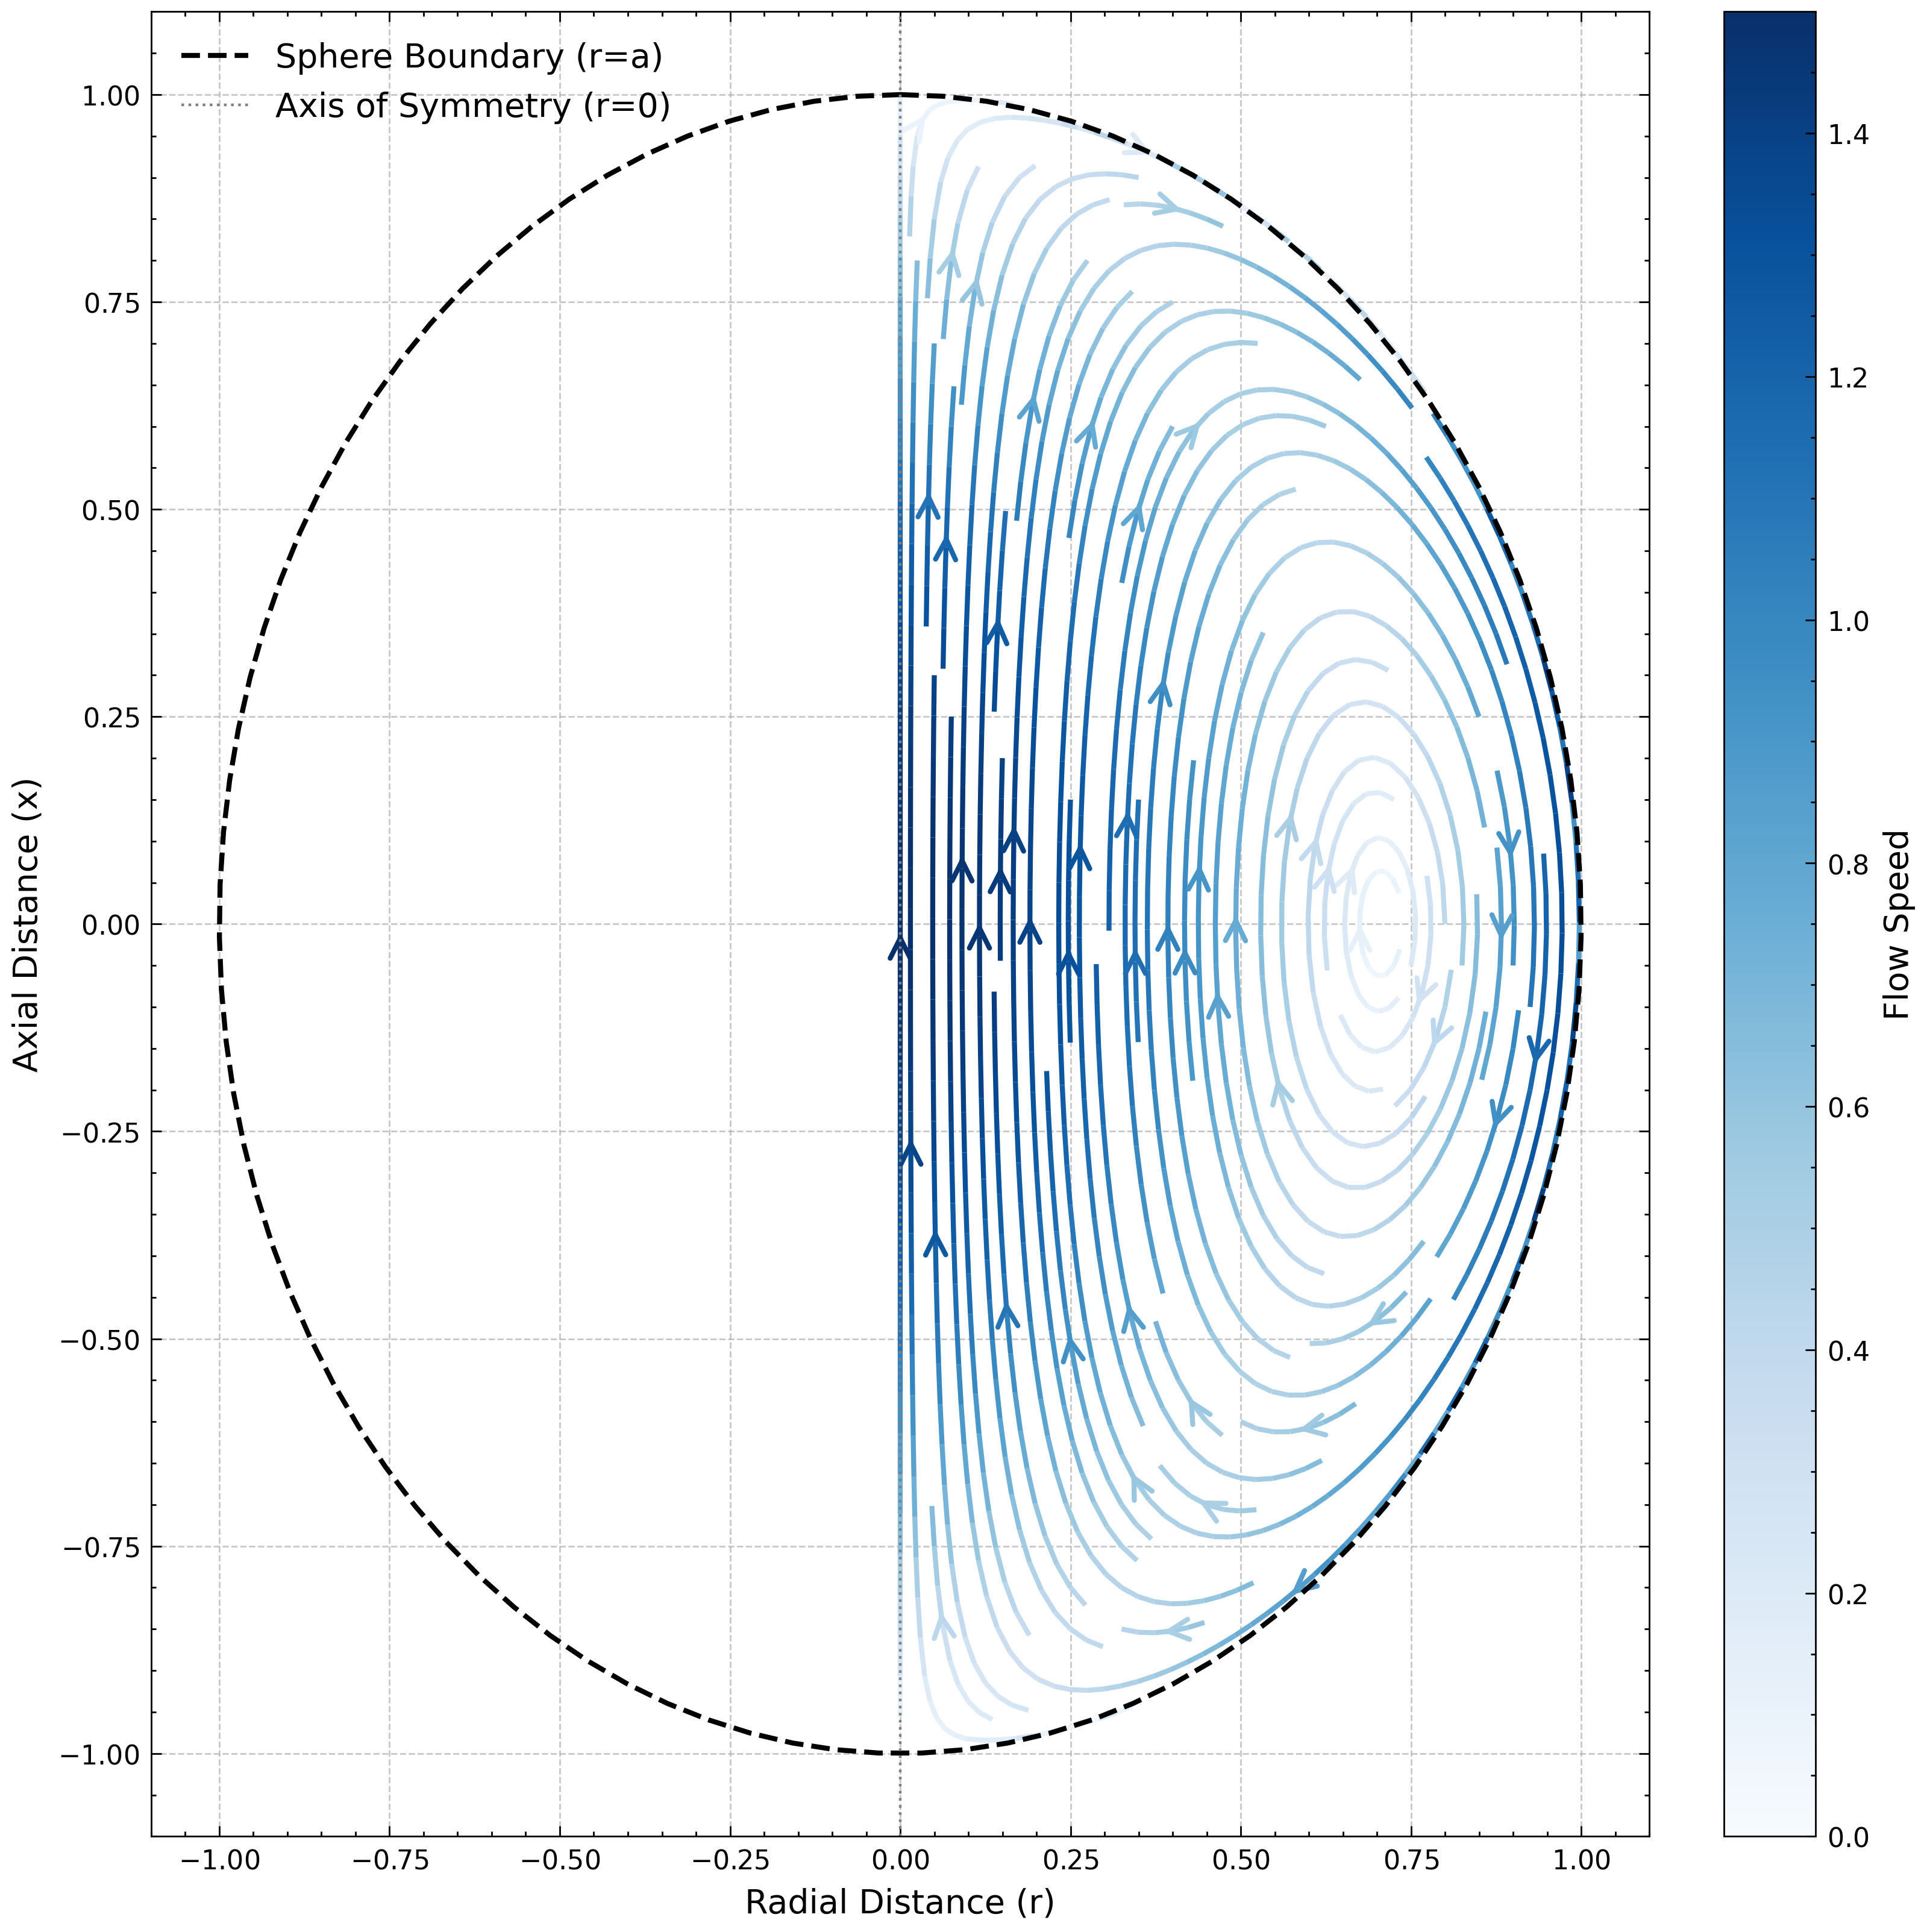

In [2]:
####Import Ollie Tools MAC
import sys
dirPath = "/Users/olliejackson/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)

oj.thesis_plot_settings()

import numpy as np
import matplotlib.pyplot as plt

# Define constants for Hill's Spherical Vortex
a = 1.0  # Radius of the sphere
U0 = 1.0 # Characteristic velocity (e.g., velocity at the center of the vortex)

# Create a grid for cylindrical coordinates (R, z)
# We'll plot R from 0 (axis of symmetry) to slightly more than 'a'
# and z from -'a' to 'a'. Using more points for smoother streamlines.
R_grid = np.linspace(0, 1.1 * a, 200)  # Radial distance (R)
Z_grid = np.linspace(-1.1 * a, 1.1 * a, 200) # Axial distance (z)

# Create 2D meshgrids from the 1D arrays
RR, ZZ = np.meshgrid(R_grid, Z_grid)

# Calculate r^2 (squared distance from the origin) for each point in the grid
r_squared = RR**2 + ZZ**2

# Initialize velocity components as zero arrays with the same shape as RR and ZZ
u_R = np.zeros_like(RR)
u_z = np.zeros_like(ZZ)

# Calculate velocity components ONLY for points inside the sphere (r <= a)
# We use boolean indexing to apply the formulas conditionally.
# The 'inside_sphere' mask will be True for points within or on the sphere boundary.
inside_sphere = r_squared <= a**2

# Apply Hill's vortex velocity equations for points inside the sphere
# u_R = (3/2) * U0 * (R * z) / a^2
u_R[inside_sphere] = (3/2) * U0 * (RR[inside_sphere] * ZZ[inside_sphere]) / (a**2)

# u_z = (3/2) * U0 * (1 - (2 * R^2 + z^2) / a^2)
u_z[inside_sphere] = (3/2) * U0 * (1 - (2 * RR[inside_sphere]**2 + ZZ[inside_sphere]**2) / (a**2))

# Calculate the magnitude of the velocity (speed) for coloring the streamlines
speed = np.sqrt(u_R**2 + u_z**2)

# Create the plot
plt.figure(figsize=(8, 8)) # Set figure size for better visualization

# Plot streamlines using streamplot
# 'color=speed' will color the streamlines based on their local speed
# 'cmap' sets the colormap for the speed
# 'linewidth' adjusts the thickness of the streamlines
# 'density' controls how many streamlines are drawn (higher value = more streamlines)
# 'arrowstyle' and 'arrowsize' control the arrows indicating flow direction
strm = plt.streamplot(RR, ZZ, u_R, u_z,
                      color=speed,
                      cmap='Blues', # A good colormap for showing magnitude
                      linewidth=1.5,
                      density=1.5,
                      arrowstyle='->',
                      arrowsize=1.5)

# Add a colorbar to indicate the mapping of color to flow speed
plt.colorbar(strm.lines, label='Flow Speed')

# Add the boundary of the sphere for visual reference
# We generate points on a circle with radius 'a'
theta = np.linspace(0, 2 * np.pi, 100)
sphere_R = a * np.sin(theta)
sphere_Z = a * np.cos(theta)
plt.plot(sphere_R, sphere_Z, 'k--', linewidth=1.5, label='Sphere Boundary (r=a)')

# Add the axis of symmetry (R=0)
plt.axvline(0, color='gray', linestyle=':', linewidth=0.8, label='Axis of Symmetry (r=0)')

# Set plot limits
# We only show positive R values because the flow is axisymmetric
plt.xlim(-1.1, 1.1 * a)
plt.ylim(-1.1 * a, 1.1 * a)

# Add labels and title for clarity
plt.xlabel('Radial Distance (r)')
plt.ylabel('Axial Distance (x)')
# plt.title("Streamlines of Hill's Spherical Vortex")

# Ensure the aspect ratio is equal so the sphere appears circular
# plt.gca().set_aspect('equal', adjustable='box')

# Display the legend
plt.legend()

# Add a grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()


Thesis plot settings applied


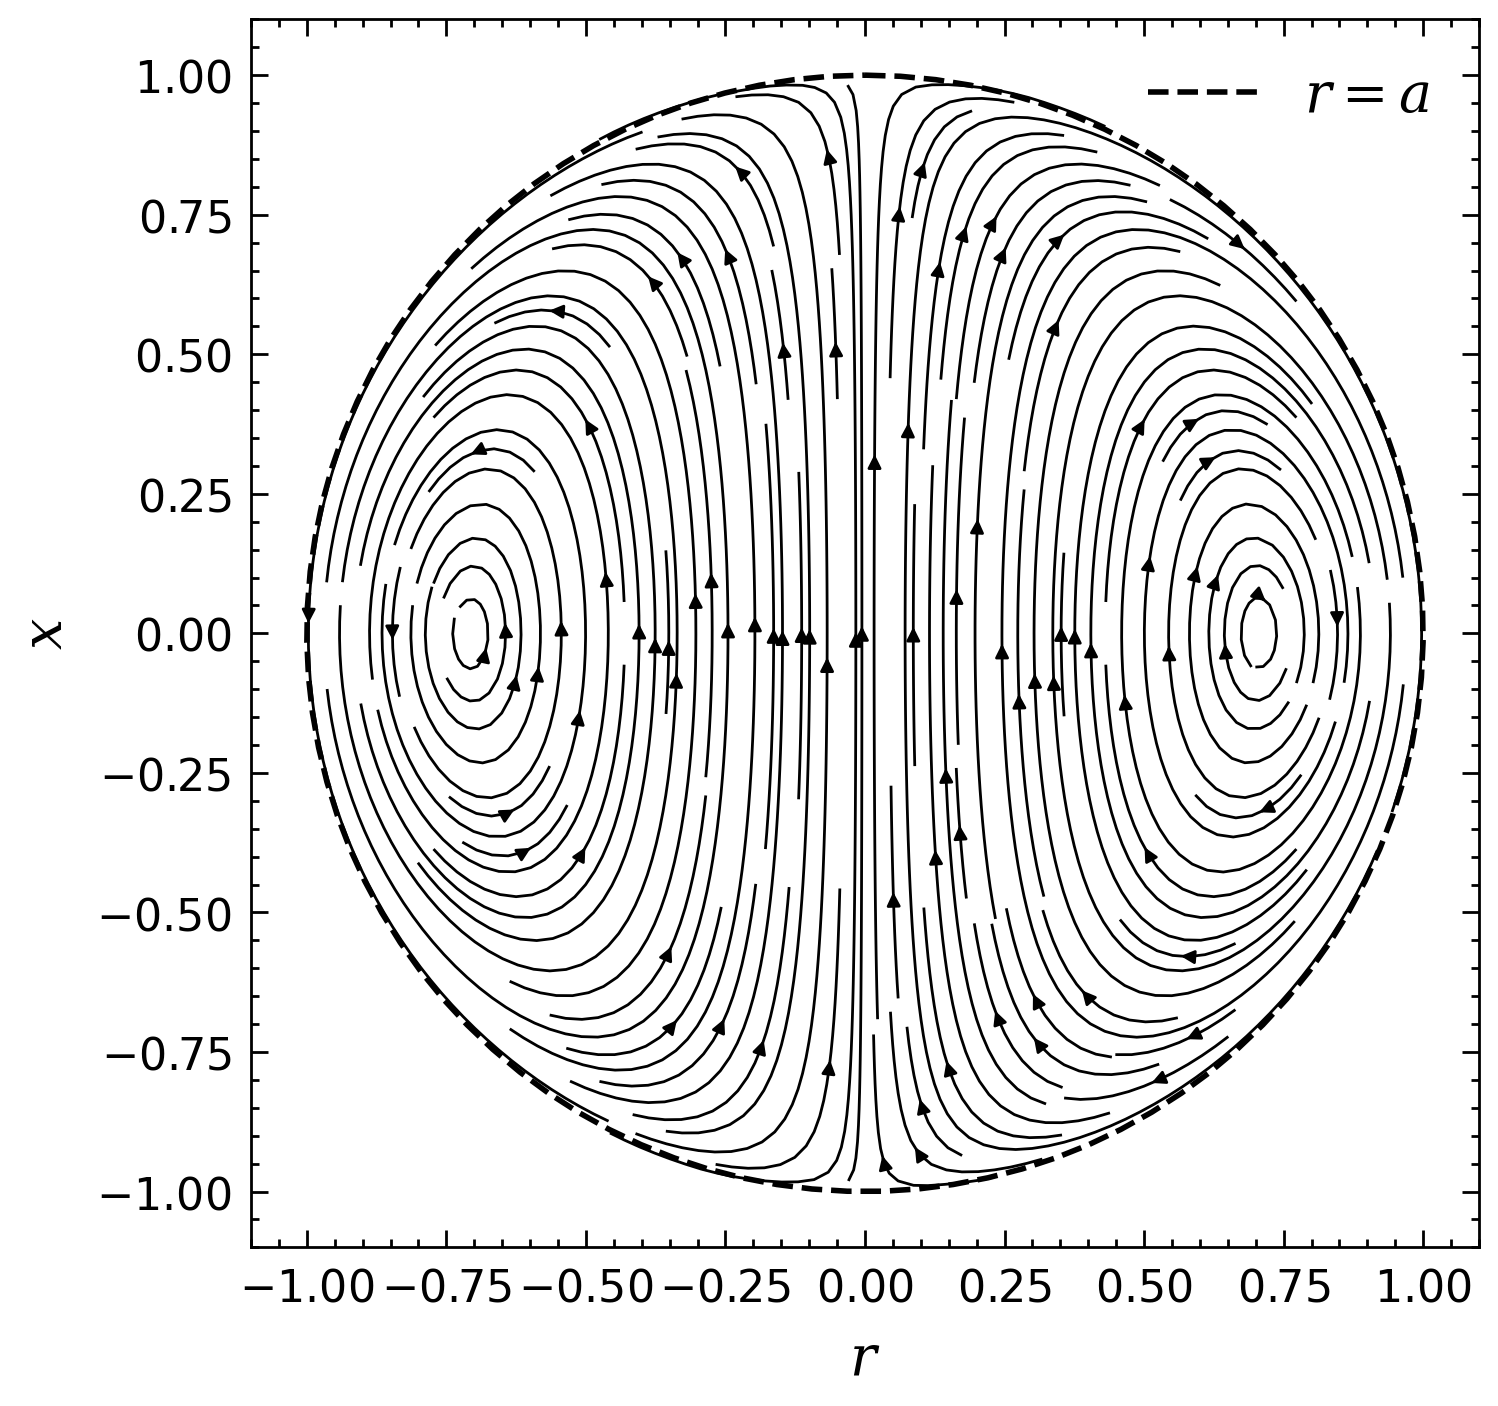

In [25]:
import numpy as np
import matplotlib.pyplot as plt
oj.thesis_plot_settings()

# Define constants for Hill's Spherical Vortex
a = 1.0  # Radius of the sphere
U0 = 1.0 # Characteristic velocity (e.g., velocity at the center of the vortex)

# Create a grid for cylindrical coordinates (R, z)
# We'll plot R from -'a' to 'a' to show the full ring, and z from -'a' to 'a'.
# Using more points for smoother streamlines.
R_grid = np.linspace(-1.1 * a, 1.1 * a, 400)  # Radial distance (R), now including negative values
Z_grid = np.linspace(-1.1 * a, 1.1 * a, 200) # Axial distance (z)

# Create 2D meshgrids from the 1D arrays
RR, ZZ = np.meshgrid(R_grid, Z_grid)

# Calculate r^2 (squared distance from the origin) for each point in the grid
r_squared = RR**2 + ZZ**2

# Initialize velocity components as zero arrays with the same shape as RR and ZZ
u_R = np.zeros_like(RR)
u_z = np.zeros_like(ZZ)

# Calculate velocity components ONLY for points inside the sphere (r <= a)
# We use boolean indexing to apply the formulas conditionally.
# The 'inside_sphere' mask will be True for points within or on the sphere boundary.
inside_sphere = r_squared <= a**2

# Apply Hill's vortex velocity equations for points inside the sphere
# u_R = (3/2) * U0 * (R * z) / a^2
u_R[inside_sphere] = (3/2) * U0 * (RR[inside_sphere] * ZZ[inside_sphere]) / (a**2)

# u_z = (3/2) * U0 * (1 - (2 * R^2 + z^2) / a^2)
u_z[inside_sphere] = (3/2) * U0 * (1 - (2 * RR[inside_sphere]**2 + ZZ[inside_sphere]**2) / (a**2))

# Calculate the magnitude of the velocity (speed) for coloring the streamlines
speed = np.sqrt(u_R**2 + u_z**2)

# Create the plot
plt.figure(figsize=(5.5, 3.5)) # Set figure size for better visualization, wider for the full ring

# Plot streamlines using streamplot
# 'color=speed' will color the streamlines based on their local speed
# 'cmap' sets the colormap for the speed
# 'linewidth' adjusts the thickness of the streamlines
# 'density' controls how many streamlines are drawn (higher value = more streamlines)
# 'arrowstyle' and 'arrowsize' control the arrows indicating flow direction
# strm = plt.streamplot(RR, ZZ, u_R, u_z,
#                       color=speed,
#                       cmap='Blues', # A good colormap for showing magnitude
#                       linewidth=0.5,
#                       density=1.5,
#                     #   arrowstyle='->',
#                       # arrowsize=1.5)
#                       arrowsize=0.5,
# )

strm = plt.streamplot(RR, ZZ, u_R, u_z,
                      color='k', # A good colormap for showing magnitude
                      linewidth=0.5,
                      density=2.5,
                      broken_streamlines=True,
                      arrowsize=0.5,
)

# Add a colorbar to indicate the mapping of color to flow speed
# plt.colorbar(strm.lines, label='$v$')

# Add the boundary of the sphere for visual reference
# We generate points on a circle with radius 'a'
theta = np.linspace(0, 2 * np.pi, 100)
sphere_R = a * np.sin(theta)
sphere_Z = a * np.cos(theta)
plt.plot(sphere_R, sphere_Z, 'k--', linewidth=1, label='$r=a$')

# Add the axis of symmetry (R=0)
# plt.axvline(0, color='gray', linestyle=':', linewidth=0.8, label='Axis of Symmetry (r=0)')

# Set plot limits
# Now showing both positive and negative R values for the full ring
plt.xlim(-1.1 * a, 1.1 * a)
plt.ylim(-1.1 * a, 1.1 * a)

# Add labels and title for clarity
plt.xlabel('$r$')
plt.ylabel('$x$')
# plt.title("Streamlines of Hill's Spherical Vortex")

# Ensure the aspect ratio is equal so the sphere appears circular
plt.gca().set_aspect('equal', adjustable='box')

# Display the legend
plt.legend()

# Add a grid for better readability
# plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()
